# **Pavan S - 24BAD085**

---

Setting up Libraries

In [17]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


Loading Dataset into Dataframe

In [ ]:
df = pd.read_csv(r"D:\SEM 4\Machine Learning\LAB\E1\data.csv", encoding='latin1')

In [19]:
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID         Country  
0        1

Inspecting Dataset

In [20]:
df.head()
df.tail()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Checking missing values


In [24]:
mv = df.isnull().sum()
print(mv)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Visualizing Sales per Product

In [27]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]
sales_per_product = (
    df.groupby("Description", as_index=False)["Sales"]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

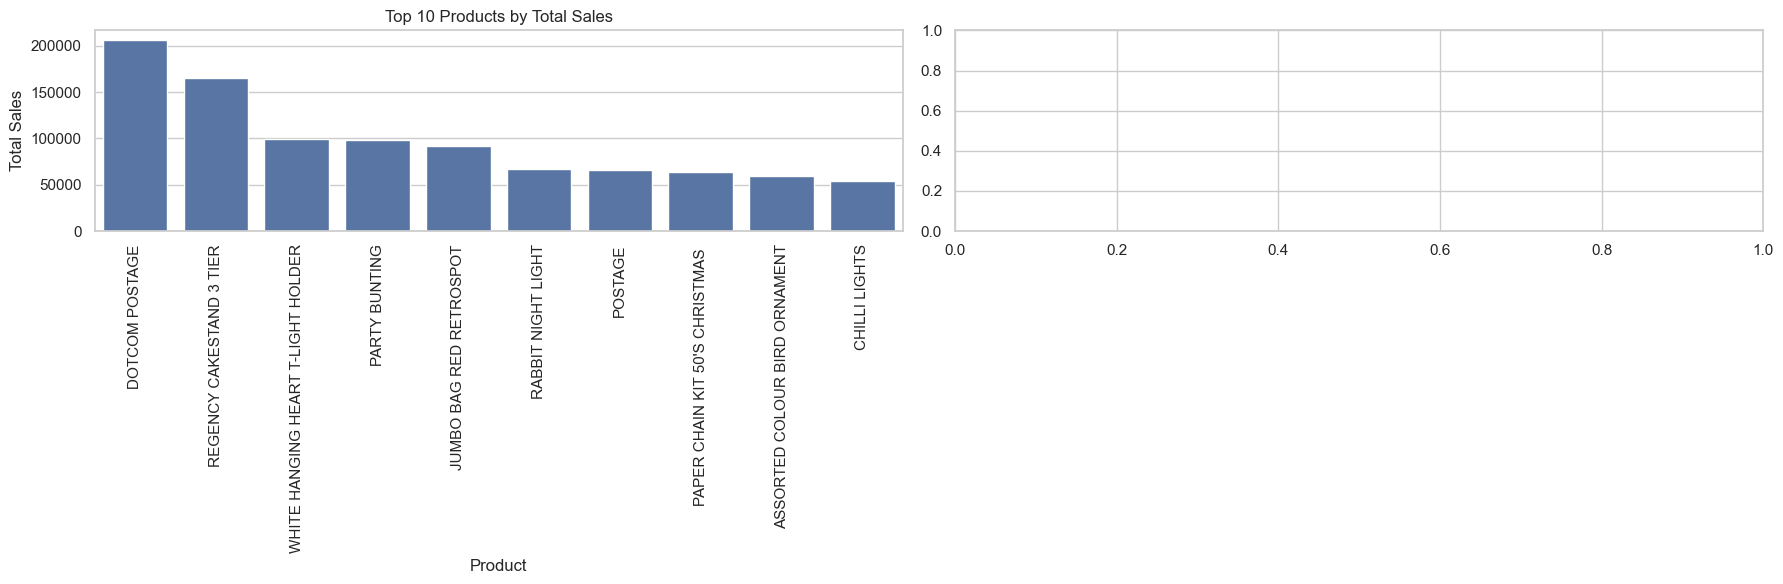

In [ ]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=sales_per_product.head(10),  
    x="Description",
    y="Sales",
    ax=axes[0]
)
axes[0].set_title("Top 10 Products by Total Sales")
axes[0].set_xlabel("Product")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

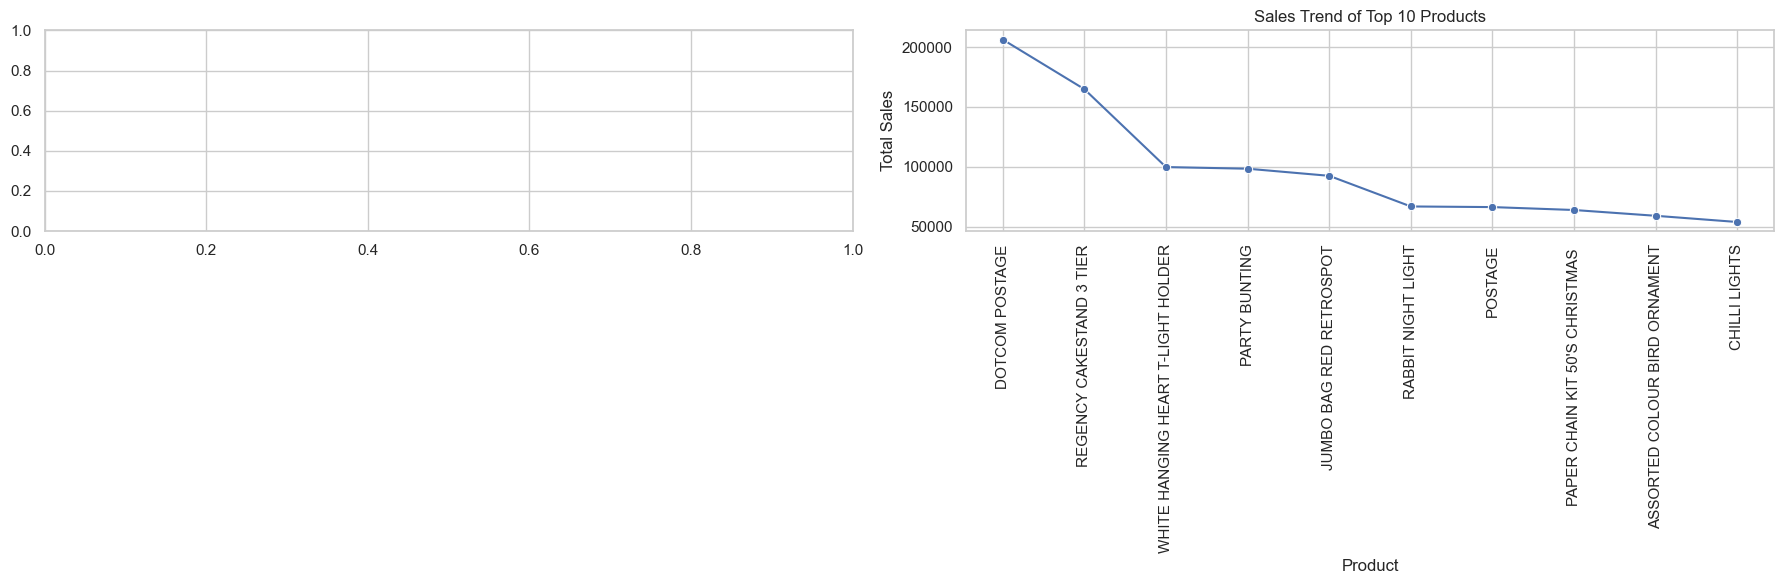

In [31]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=sales_per_product.head(10),
    x="Description",
    y="Sales",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Sales Trend of Top 10 Products")
axes[1].set_xlabel("Product")
axes[1].set_ylabel("Total Sales")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()
